
> **Course: AIML ZG528 AI and ML for Robotics**

>  **Author: Sangeetha Viswanathan**
sangeetha.viswanathan@pilani.bits-pilani.ac.in

> **Objective**:

To implement AIML techniques for learning intrinsic calibration parameters of beam sensors (e.g., LiDAR) from synthetic measurements so measured ranges map to true distances.

**Input:**

> Measured sensor readings (range)

> Optionally with incidence angle, surface reflectivity, and ambient light; synthetic dataset generated from a known physics model.

**Output:**

> Calibrated mapping from measured to true distance

> Learned parameter estimates (e.g., offset, scale, attenuation, non‑linearity)

> Model performance metrics (RMSE, MAE, R²).

**Models Compared:**
1. Linear Regression Model
2. Polynomial Regression Model
3. Physics based model
4. Deep Neural Network based Model


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit, minimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

 ### BEAM SENSOR PHYSICS AND GROUND TRUTH PARAMETERS

In [ ]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*70)
print("Beam Sensor Intrinsic Parameter Learning")
print("="*70)

print("\n[1] Defining Beam Sensor Models")
print("="*70)

# Ground truth intrinsic parameters (to be learned)
TRUE_PARAMS = {
    'offset': 0.05,           # Sensor offset (meters)
    'scale': 0.98,            # Scale factor
    'min_range': 0.1,         # Minimum detection range
    'max_range': 10.0,        # Maximum detection range
    'noise_sigma': 0.02,      # Measurement noise std dev
    'beam_width': 0.087,      # Beam width (5 degrees in radians)
    'k_attenuation': 0.01,    # Atmospheric attenuation coefficient
    'non_linearity': 0.001,   # Non-linearity coefficient
}

print("\nTrue Intrinsic Parameters:")
for param, value in TRUE_PARAMS.items():
    print(f"  {param:20s}: {value:.6f}")

### GENERATE SYNTHETIC BEAM SENSOR DATA

In [ ]:
def beam_sensor_model(true_distance, params):
    """
    Complete beam sensor measurement model

    measured = scale * (true_distance + offset) * (1 + non_linearity * true_distance^2)
               * exp(-k_attenuation * true_distance) + noise

    With saturation at min/max range
    """
    offset = params['offset']
    scale = params['scale']
    k_att = params['k_attenuation']
    non_lin = params['non_linearity']
    noise_sigma = params['noise_sigma']
    min_range = params['min_range']
    max_range = params['max_range']

    # Core measurement model
    measured = scale * (true_distance + offset) * \
               (1 + non_lin * true_distance**2) * \
               np.exp(-k_att * true_distance)

    # Add Gaussian noise
    measured += np.random.normal(0, noise_sigma, size=measured.shape)

    # Saturation effects
    measured = np.clip(measured, min_range, max_range)

    # Simulate occasional outliers (multi-path, specular reflection)
    outlier_prob = 0.02
    outlier_mask = np.random.random(measured.shape) < outlier_prob
    measured[outlier_mask] += np.random.uniform(-0.5, 0.5, size=np.sum(outlier_mask))

    return measured

def generate_beam_sensor_data(n_samples=2000, seed=42):
    """Generate synthetic beam sensor measurements"""
    np.random.seed(seed)

    # True distances: uniform sampling + some concentrated near boundaries
    true_distances = np.concatenate([
        np.random.uniform(0.1, 10.0, int(n_samples * 0.7)),
        np.random.uniform(0.1, 1.0, int(n_samples * 0.15)),  # Near field
        np.random.uniform(8.0, 10.0, int(n_samples * 0.15))  # Far field
    ])
    np.random.shuffle(true_distances)

    # Generate measurements
    measurements = beam_sensor_model(true_distances, TRUE_PARAMS)

    # Additional features that might be available
    incidence_angles = np.random.uniform(0, 60, n_samples)  # degrees
    surface_reflectivity = np.random.uniform(0.1, 0.9, n_samples)
    ambient_light = np.random.uniform(0, 1000, n_samples)  # lux

    data = pd.DataFrame({
        'true_distance': true_distances,
        'measured_distance': measurements,
        'incidence_angle': incidence_angles,
        'surface_reflectivity': surface_reflectivity,
        'ambient_light': ambient_light
    })

    return data

print("\n[2] Generating Synthetic Beam Sensor Data")
print("="*70)

sensor_data = generate_beam_sensor_data(n_samples=2000, seed=42)
print(f"\nGenerated {len(sensor_data)} measurements")
print("\nFirst few samples:")
print(sensor_data.head(10))

print("\nData Statistics:")
print(sensor_data.describe())

# Visualize raw data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Measured vs True
axes[0, 0].scatter(sensor_data['true_distance'], sensor_data['measured_distance'],
                   alpha=0.3, s=10)
axes[0, 0].plot([0, 10], [0, 10], 'r--', linewidth=2, label='Perfect Measurement')
axes[0, 0].set_xlabel('True Distance (m)', fontsize=11)
axes[0, 0].set_ylabel('Measured Distance (m)', fontsize=11)
axes[0, 0].set_title('Raw Sensor Measurements', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Error vs Distance
error = sensor_data['measured_distance'] - sensor_data['true_distance']
axes[0, 1].scatter(sensor_data['true_distance'], error, alpha=0.3, s=10)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('True Distance (m)', fontsize=11)
axes[0, 1].set_ylabel('Measurement Error (m)', fontsize=11)
axes[0, 1].set_title('Measurement Error vs Distance', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Error distribution
axes[1, 0].hist(error, bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Measurement Error (m)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Error Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Distance distribution
axes[1, 1].hist(sensor_data['true_distance'], bins=50, alpha=0.7,
                color='green', edgecolor='black')
axes[1, 1].set_xlabel('True Distance (m)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Distance Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### MODEL 1: LINEAR CALIBRATION (OFFSET + SCALE)

In [ ]:
print("\n[3] Model 1: Linear Calibration (Offset + Scale)")
print("="*70)

def linear_model(measured, offset, scale):
    """Simple linear calibration: true = scale * measured + offset"""
    return scale * measured + offset

# Fit using least squares
from scipy.optimize import curve_fit

X_train, X_test, y_train, y_test = train_test_split(
    sensor_data['measured_distance'].values,
    sensor_data['true_distance'].values,
    test_size=0.2,
    random_state=42
)

# Fit linear model
popt_linear, _ = curve_fit(linear_model, X_train, y_train, p0=[0.0, 1.0])
learned_offset, learned_scale = popt_linear

print(f"\nLearned Parameters:")
print(f"  Offset: {learned_offset:.6f} (True: {-TRUE_PARAMS['offset']/TRUE_PARAMS['scale']:.6f})")
print(f"  Scale:  {learned_scale:.6f} (True: {1.0/TRUE_PARAMS['scale']:.6f})")

# Predictions
y_pred_train_linear = linear_model(X_train, learned_offset, learned_scale)
y_pred_test_linear = linear_model(X_test, learned_offset, learned_scale)

# Metrics
print(f"\nPerformance Metrics:")
print(f"  Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_linear)):.6f} m")
print(f"  Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_linear)):.6f} m")
print(f"  Test MAE:   {mean_absolute_error(y_test, y_pred_test_linear):.6f} m")
print(f"  Test R²:    {r2_score(y_test, y_pred_test_linear):.6f}")

### MODEL 2: POLYNOMIAL CALIBRATION (NON-LINEAR)

In [ ]:
print("\n[4] Model 2: Polynomial Calibration (Non-linear)")
print("="*70)

def polynomial_model(measured, offset, scale, a2, a3):
    """Polynomial calibration: true = scale*measured + offset + a2*measured^2 + a3*measured^3"""
    return scale * measured + offset + a2 * measured**2 + a3 * measured**3

# Fit polynomial model
popt_poly, _ = curve_fit(polynomial_model, X_train, y_train,
                         p0=[0.0, 1.0, 0.0, 0.0], maxfev=10000)

print(f"\nLearned Parameters:")
print(f"  Offset: {popt_poly[0]:.6f}")
print(f"  Scale:  {popt_poly[1]:.6f}")
print(f"  a2:     {popt_poly[2]:.6f}")
print(f"  a3:     {popt_poly[3]:.6f}")

# Predictions
y_pred_train_poly = polynomial_model(X_train, *popt_poly)
y_pred_test_poly = polynomial_model(X_test, *popt_poly)

# Metrics
print(f"\nPerformance Metrics:")
print(f"  Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_poly)):.6f} m")
print(f"  Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_poly)):.6f} m")
print(f"  Test MAE:   {mean_absolute_error(y_test, y_pred_test_poly):.6f} m")
print(f"  Test R²:    {r2_score(y_test, y_pred_test_poly):.6f}")

###  MODEL 3: PHYSICS-BASED MODEL

In [ ]:
print("\n[5] Model 3: Physics-Based Model with Attenuation")
print("="*70)

def physics_model(measured, offset, scale, k_att, non_lin):
    """
    Physics-based inverse model
    Inverse of: measured = scale * (true + offset) * (1 + non_lin*true^2) * exp(-k_att*true)
    """
    # Simplified iterative solution (Newton's method)
    true_est = measured / scale - offset  # Initial guess

    for _ in range(10):  # Fixed iterations
        f = scale * (true_est + offset) * (1 + non_lin * true_est**2) * \
            np.exp(-k_att * true_est) - measured
        df = scale * ((1 + non_lin * true_est**2) * np.exp(-k_att * true_est) + \
                     (true_est + offset) * (2 * non_lin * true_est * np.exp(-k_att * true_est) - \
                     k_att * (1 + non_lin * true_est**2) * np.exp(-k_att * true_est)))
        df = np.where(np.abs(df) > 1e-10, df, 1e-10)  # Avoid division by zero
        true_est = true_est - f / df

    return true_est

# Use optimization to find parameters
def objective_physics(params, measured, true):
    """Objective function for physics-based model"""
    try:
        predicted = physics_model(measured, *params)
        return np.sum((predicted - true)**2)
    except:
        return 1e10

# Initial guess
x0 = [0.0, 1.0, 0.01, 0.001]
bounds = [(-1, 1), (0.5, 1.5), (0, 0.1), (-0.01, 0.01)]

result = minimize(objective_physics, x0, args=(X_train, y_train),
                  method='L-BFGS-B', bounds=bounds)
popt_physics = result.x

print(f"\nLearned Parameters:")
print(f"  Offset:         {popt_physics[0]:.6f} (True: {TRUE_PARAMS['offset']:.6f})")
print(f"  Scale:          {popt_physics[1]:.6f} (True: {TRUE_PARAMS['scale']:.6f})")
print(f"  k_attenuation:  {popt_physics[2]:.6f} (True: {TRUE_PARAMS['k_attenuation']:.6f})")
print(f"  non_linearity:  {popt_physics[3]:.6f} (True: {TRUE_PARAMS['non_linearity']:.6f})")

# Predictions
y_pred_train_physics = physics_model(X_train, *popt_physics)
y_pred_test_physics = physics_model(X_test, *popt_physics)

# Metrics
print(f"\nPerformance Metrics:")
print(f"  Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_physics)):.6f} m")
print(f"  Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_physics)):.6f} m")
print(f"  Test MAE:   {mean_absolute_error(y_test, y_pred_test_physics):.6f} m")
print(f"  Test R²:    {r2_score(y_test, y_pred_test_physics):.6f}")


###  MODEL 4: DEEP NEURAL NETWORK (DNN)

In [ ]:
print("\n[6] Model 4: Deep Neural Network (DNN)")
print("="*70)

# Prepare data with additional features
X_train_full = sensor_data.loc[sensor_data.index.isin(
    pd.Series(X_train).index if hasattr(pd.Series(X_train), 'index') else range(len(X_train))
)].copy()

# Create proper train/test split with all features
train_indices = np.random.choice(len(sensor_data), size=int(0.8*len(sensor_data)), replace=False)
test_indices = np.array([i for i in range(len(sensor_data)) if i not in train_indices])

X_train_dnn = sensor_data.iloc[train_indices][
    ['measured_distance', 'incidence_angle', 'surface_reflectivity', 'ambient_light']
].values
y_train_dnn = sensor_data.iloc[train_indices]['true_distance'].values

X_test_dnn = sensor_data.iloc[test_indices][
    ['measured_distance', 'incidence_angle', 'surface_reflectivity', 'ambient_light']
].values
y_test_dnn = sensor_data.iloc[test_indices]['true_distance'].values

# Standardize features
scaler = StandardScaler()
X_train_dnn_scaled = scaler.fit_transform(X_train_dnn)
X_test_dnn_scaled = scaler.transform(X_test_dnn)

# Build DNN using numpy (simple implementation)
class DNNCalibration:
    def __init__(self, input_dim, hidden_dims=[64, 32, 16], output_dim=1):
        """Simple feedforward neural network"""
        self.layers = []
        self.weights = []
        self.biases = []

        # Initialize weights
        dims = [input_dim] + hidden_dims + [output_dim]
        for i in range(len(dims)-1):
            w = np.random.randn(dims[i], dims[i+1]) * np.sqrt(2.0 / dims[i])
            b = np.zeros((1, dims[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(float)

    def forward(self, X):
        """Forward pass"""
        self.activations = [X]
        self.z_values = []

        for i in range(len(self.weights)-1):
            z = np.dot(self.activations[-1], self.weights[i]) + self.biases[i]
            self.z_values.append(z)
            a = self.relu(z)
            self.activations.append(a)

        # Output layer (linear)
        z = np.dot(self.activations[-1], self.weights[-1]) + self.biases[-1]
        self.z_values.append(z)
        self.activations.append(z)

        return self.activations[-1]

    def backward(self, X, y, learning_rate=0.001):
        """Backward pass with gradient descent"""
        m = X.shape[0]

        # Output layer gradient
        dz = self.activations[-1] - y.reshape(-1, 1)

        # Backpropagate
        for i in range(len(self.weights)-1, -1, -1):
            dw = np.dot(self.activations[i].T, dz) / m
            db = np.sum(dz, axis=0, keepdims=True) / m

            if i > 0:
                dz = np.dot(dz, self.weights[i].T) * self.relu_derivative(self.z_values[i-1])

            # Update weights
            self.weights[i] -= learning_rate * dw
            self.biases[i] -= learning_rate * db

    def train(self, X, y, epochs=100, batch_size=32, learning_rate=0.001, verbose=True):
        """Train the network"""
        n_samples = X.shape[0]
        history = {'loss': []}

        for epoch in range(epochs):
            # Shuffle data
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # Mini-batch training
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]

                # Forward and backward
                self.forward(X_batch)
                self.backward(X_batch, y_batch, learning_rate)

            # Calculate loss
            y_pred = self.forward(X)
            loss = np.mean((y_pred.flatten() - y)**2)
            history['loss'].append(loss)

            if verbose and (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1}/{epochs}, Loss: {loss:.6f}")

        return history

    def predict(self, X):
        """Make predictions"""
        return self.forward(X).flatten()

# Create and train DNN
print("\nTraining Deep Neural Network...")
dnn_model = DNNCalibration(input_dim=4, hidden_dims=[64, 32, 16], output_dim=1)
history = dnn_model.train(X_train_dnn_scaled, y_train_dnn,
                          epochs=150, batch_size=32, learning_rate=0.01, verbose=True)

# Predictions
y_pred_train_dnn = dnn_model.predict(X_train_dnn_scaled)
y_pred_test_dnn = dnn_model.predict(X_test_dnn_scaled)

# Metrics
print(f"\nPerformance Metrics:")
print(f"  Train RMSE: {np.sqrt(mean_squared_error(y_train_dnn, y_pred_train_dnn)):.6f} m")
print(f"  Test RMSE:  {np.sqrt(mean_squared_error(y_test_dnn, y_pred_test_dnn)):.6f} m")
print(f"  Test MAE:   {mean_absolute_error(y_test_dnn, y_pred_test_dnn):.6f} m")
print(f"  Test R²:    {r2_score(y_test_dnn, y_pred_test_dnn):.6f}")

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('DNN Training History', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### MODEL COMPARISON

In [ ]:
print("\n[7] Model Comparison")
print("="*70)

# Gather all predictions on common test set
common_test_indices = test_indices[:min(len(test_indices), len(X_test))]
X_test_common = sensor_data.iloc[common_test_indices]['measured_distance'].values
y_test_common = sensor_data.iloc[common_test_indices]['true_distance'].values

# Predictions from all models
pred_linear = linear_model(X_test_common, learned_offset, learned_scale)
pred_poly = polynomial_model(X_test_common, *popt_poly)
pred_physics = physics_model(X_test_common, *popt_physics)
pred_dnn = dnn_model.predict(scaler.transform(
    sensor_data.iloc[common_test_indices][
        ['measured_distance', 'incidence_angle', 'surface_reflectivity', 'ambient_light']
    ].values
))

# Calculate metrics
models = {
    'Linear': pred_linear,
    'Polynomial': pred_poly,
    'Physics-Based': pred_physics,
    'DNN': pred_dnn
}

results = []
for name, predictions in models.items():
    rmse = np.sqrt(mean_squared_error(y_test_common, predictions))
    mae = mean_absolute_error(y_test_common, predictions)
    r2 = r2_score(y_test_common, predictions)
    results.append({
        'Model': name,
        'RMSE (m)': rmse,
        'MAE (m)': mae,
        'R² Score': r2
    })

results_df = pd.DataFrame(results)
print("\nModel Performance Comparison:")
print(results_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
colors = ['blue', 'green', 'orange', 'red']

for idx, (name, predictions) in enumerate(models.items()):
    ax = axes[idx // 2, idx % 2]

    # Scatter plot
    ax.scatter(y_test_common, predictions, alpha=0.4, s=20, color=colors[idx], label='Predictions')
    ax.plot([y_test_common.min(), y_test_common.max()],
            [y_test_common.min(), y_test_common.max()],
            'k--', linewidth=2, label='Perfect')

    # Calculate and display metrics
    rmse = np.sqrt(mean_squared_error(y_test_common, predictions))
    r2 = r2_score(y_test_common, predictions)

    ax.set_xlabel('True Distance (m)', fontsize=11)
    ax.set_ylabel('Predicted Distance (m)', fontsize=11)
    ax.set_title(f'{name} Model\nRMSE={rmse:.4f}m, R²={r2:.4f}',
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (name, predictions) in enumerate(models.items()):
    ax = axes[idx // 2, idx % 2]
    errors = predictions - y_test_common

    ax.scatter(y_test_common, errors, alpha=0.4, s=20, color=colors[idx])
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax.set_xlabel('True Distance (m)', fontsize=11)
    ax.set_ylabel('Prediction Error (m)', fontsize=11)
    ax.set_title(f'{name} Model - Residuals', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


##### LEARNED PARAMETERS VS TRUE PARAMETERS

Beam Sensor Intrinsic Parameter Learning

[1] Defining Beam Sensor Models

True Intrinsic Parameters:
  offset              : 0.050000
  scale               : 0.980000
  min_range           : 0.100000
  max_range           : 10.000000
  noise_sigma         : 0.020000
  beam_width          : 0.087000
  k_attenuation       : 0.010000
  non_linearity       : 0.001000

[2] Generating Synthetic Beam Sensor Data

Generated 2000 measurements

First few samples:
   true_distance  measured_distance  incidence_angle  surface_reflectivity  \
0       2.548746           2.484663         2.315494              0.287223   
1       3.769357           3.658230        52.732869              0.570469   
2       9.493967           9.295874        18.895994              0.556552   
3       1.947014           1.910388         7.738734              0.487413   
4       5.311386           5.130301        28.107674              0.539983   
5       0.669836           0.707359        35.898365              0.49343

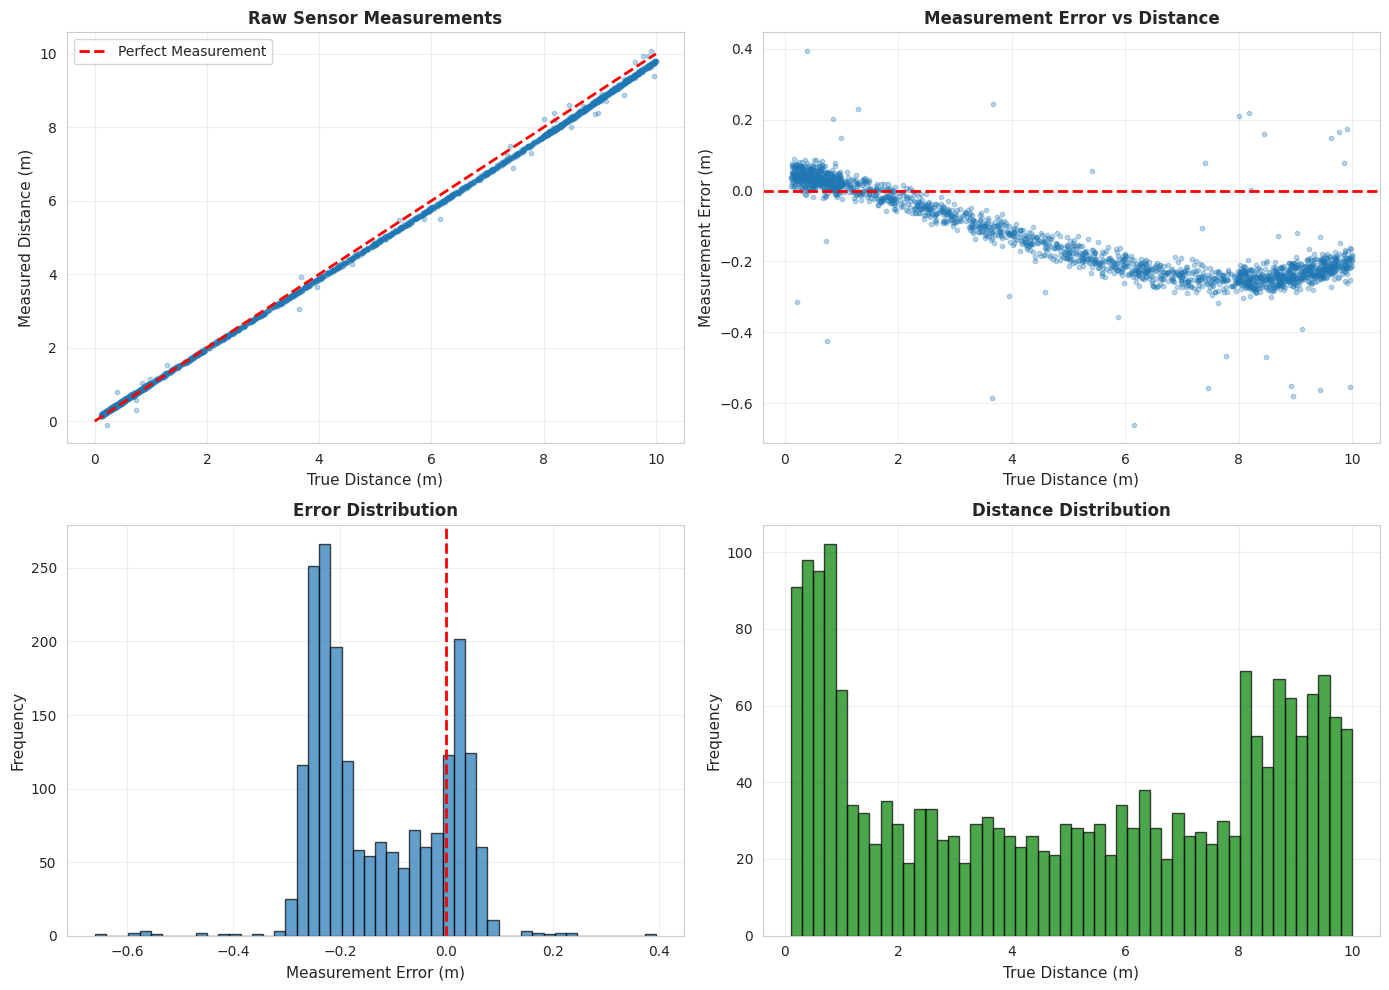


[3] Model 1: Linear Calibration (Offset + Scale)

Learned Parameters:
  Offset: -0.029128 (True: -0.051020)
  Scale:  1.032500 (True: 1.020408)

Performance Metrics:
  Train RMSE: 0.059797 m
  Test RMSE:  0.056273 m
  Test MAE:   0.038615 m
  Test R²:    0.999719

[4] Model 2: Polynomial Calibration (Non-linear)

Learned Parameters:
  Offset: -0.046246
  Scale:  1.018084
  a2:     0.010775
  a3:     -0.001048

Performance Metrics:
  Train RMSE: 0.045960 m
  Test RMSE:  0.040370 m
  Test MAE:   0.019647 m
  Test R²:    0.999855

[5] Model 3: Physics-Based Model with Attenuation

Learned Parameters:
  Offset:         0.000000 (True: 0.050000)
  Scale:          1.000000 (True: 0.980000)
  k_attenuation:  0.010000 (True: 0.010000)
  non_linearity:  0.001000 (True: 0.001000)

Performance Metrics:
  Train RMSE: 0.090254 m
  Test RMSE:  0.092137 m
  Test MAE:   0.071288 m
  Test R²:    0.999247

[6] Model 4: Deep Neural Network (DNN)

Training Deep Neural Network...
  Epoch 20/150, Loss: 0.0

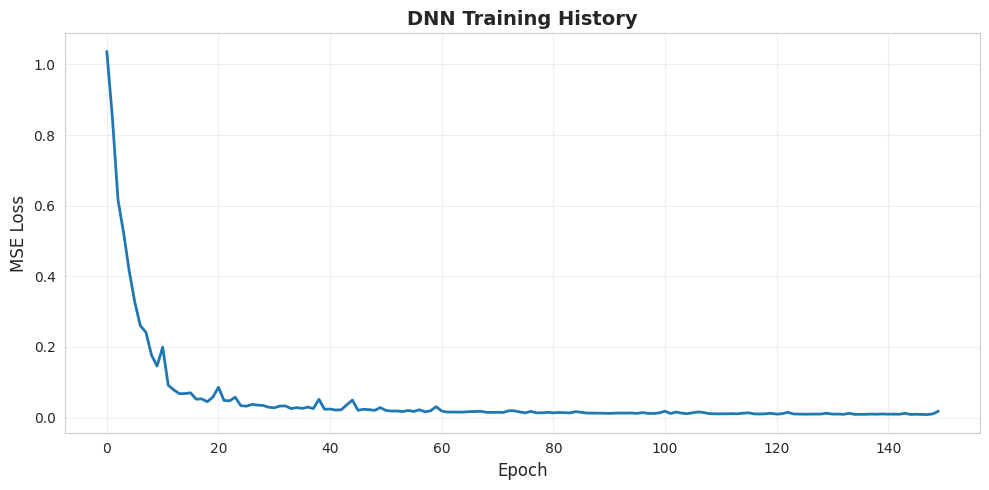


[7] Model Comparison

Model Performance Comparison:
        Model  RMSE (m)  MAE (m)  R² Score
       Linear  0.061380 0.038827  0.999677
   Polynomial  0.046717 0.021518  0.999813
Physics-Based  0.093190 0.070956  0.999256
          DNN  0.142608 0.113873  0.998258


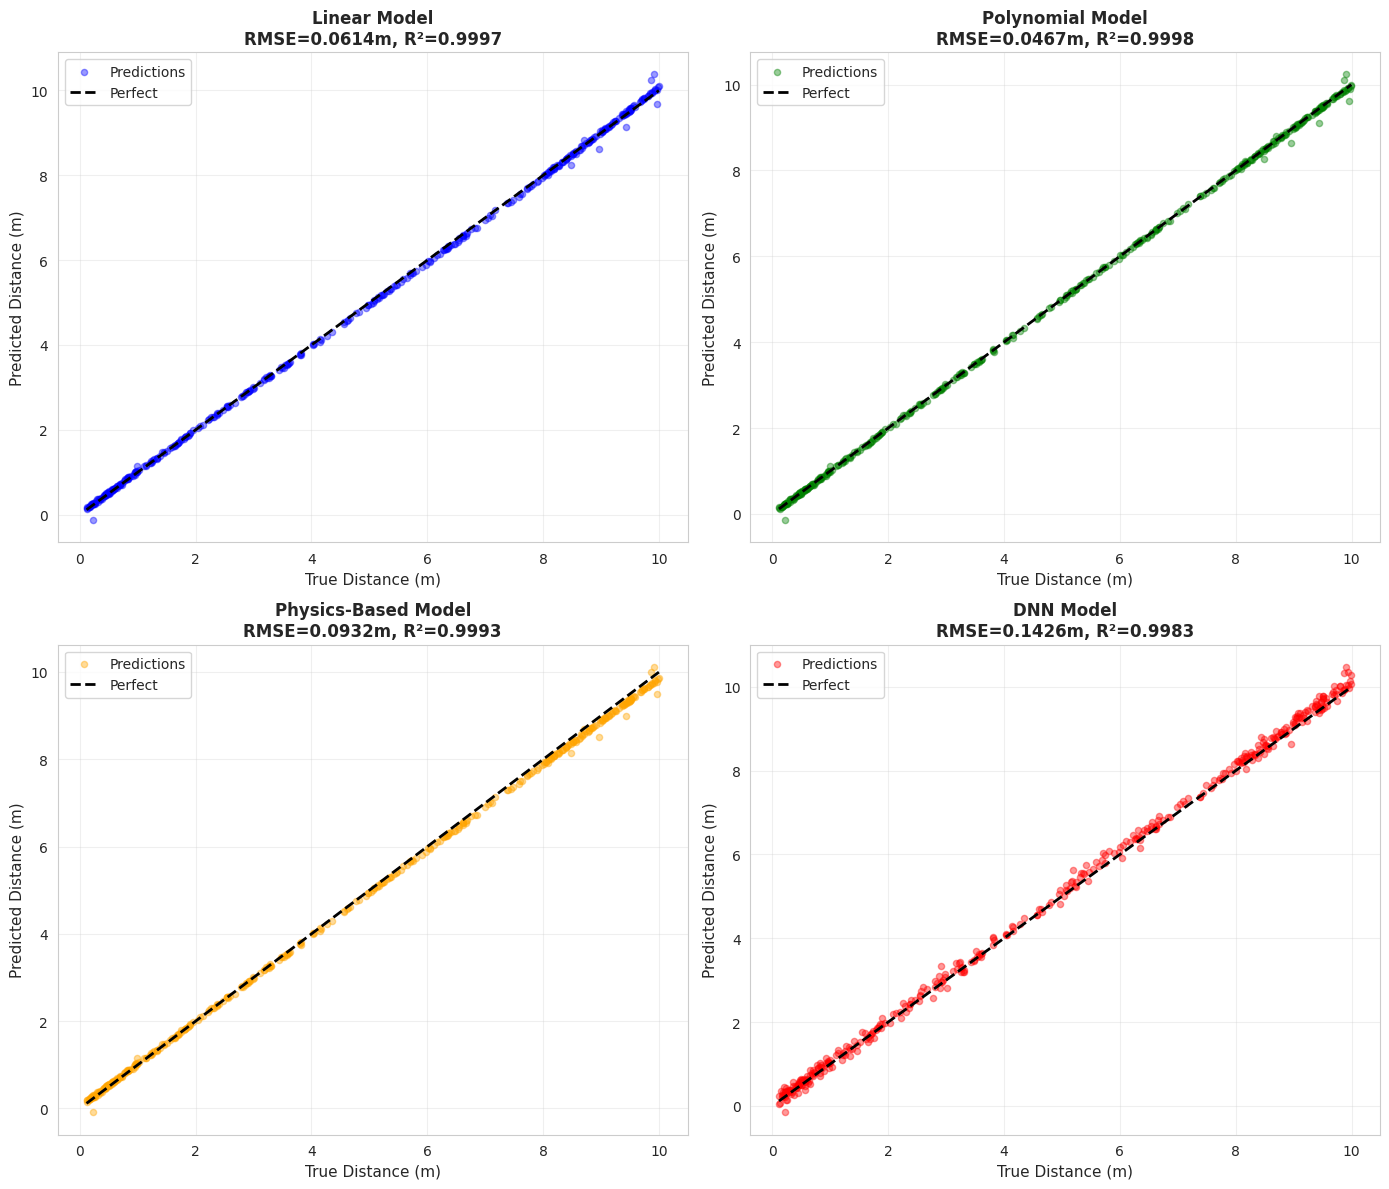

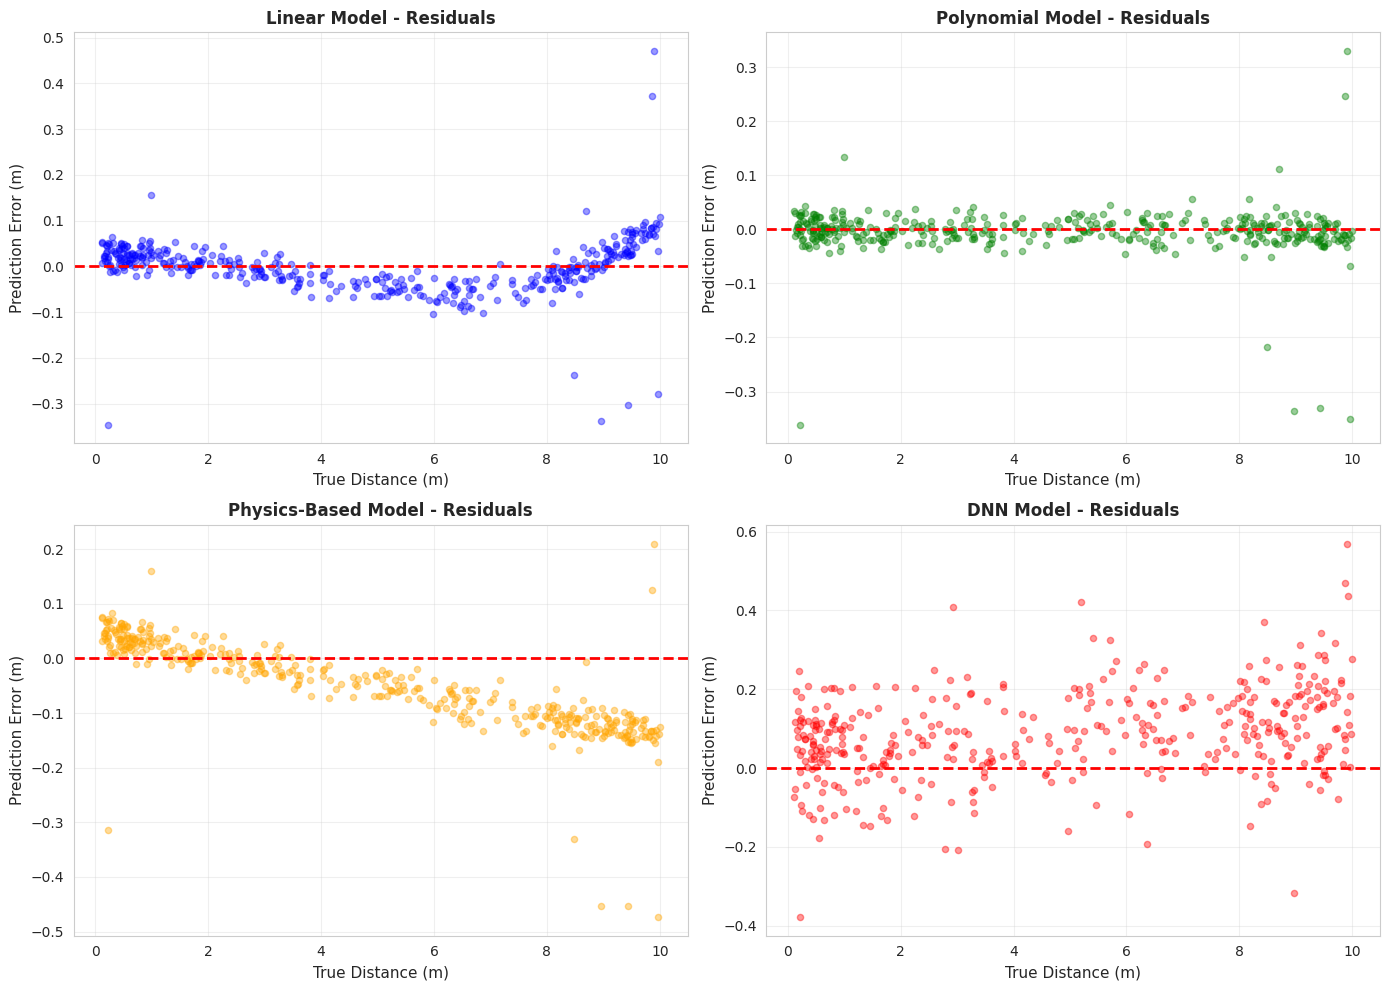


[8] Learned Parameters vs True Parameters

Parameter Recovery (Physics-Based Model):
    Parameter  True Value  Physics Model    Error %
       offset       0.050          0.000 100.000000
        scale       0.980          1.000   2.040816
k_attenuation       0.010          0.010   0.000000
non_linearity       0.001          0.001   0.000000


In [ ]:

print("\n[8] Learned Parameters vs True Parameters")
print("="*70)

param_comparison = pd.DataFrame({
    'Parameter': ['offset', 'scale', 'k_attenuation', 'non_linearity'],
    'True Value': [
        TRUE_PARAMS['offset'],
        TRUE_PARAMS['scale'],
        TRUE_PARAMS['k_attenuation'],
        TRUE_PARAMS['non_linearity']
    ],
    'Physics Model': [
        popt_physics[0],
        popt_physics[1],
        popt_physics[2],
        popt_physics[3]
    ],
    'Error %': [
        abs(popt_physics[0] - TRUE_PARAMS['offset']) / TRUE_PARAMS['offset'] * 100,
        abs(popt_physics[1] - TRUE_PARAMS['scale']) / TRUE_PARAMS['scale'] * 100,
        abs(popt_physics[2] - TRUE_PARAMS['k_attenuation']) / TRUE_PARAMS['k_attenuation'] * 100,
        abs(popt_physics[3] - TRUE_PARAMS['non_linearity']) / abs(TRUE_PARAMS['non_linearity']) * 100
    ]
})

print("\nParameter Recovery (Physics-Based Model):")
print(param_comparison.to_string(index=False))


**Exercises**
1. In Linear Regression model , replace MSE with robust losses (Huber, Tukey) or use outlier detection before fitting
2. Replace synthetic dataset with sensor-specific data and validate on real sensor data.
3. Add adaptive calibration to track parameter drift over time.